# Retrieval and RAG over tasting notes

Retrieval asks a different question from the models so far: not "what does this prose imply about
price" but "what did wines that taste like this actually cost".

The store holds tasting notes only. No price, no critic score, no winery in the embedded text -- if
those went in, similarity search would find the answer instead of a comparable wine, and the whole
evaluation would be a leak with extra steps. Prices live in the metadata, retrieved *after* the
match, which is how a comparable is supposed to work.

In [1]:
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

from pricer import vectors
from pricer.agents import ClassicalAgent, FrontierAgent, NeighboursAgent, price_all, setup_logging
from pricer.evaluator import Report, leaderboard
from pricer.items import Wine

setup_logging()
train, val, test = Wine.load_local()
collection = vectors.load()  # built by scripts/vectors.py
encoder = vectors.encoder()
print(f"{collection.count():,} tasting notes embedded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

49,895 tasting notes embedded


### Does the embedding space know about price?

If wines that taste alike also cost alike, the neighbourhood structure carries price information and
retrieval will help. Colour a t-SNE projection by price and look for gradient rather than noise.

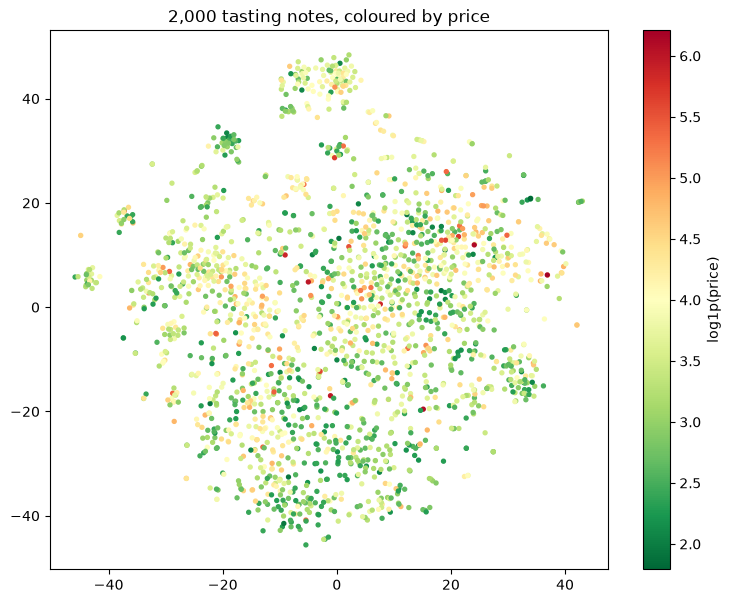

Most common varieties in the sample: [('Pinot Noir', 224), ('Chardonnay', 212), ('Cabernet Sauvignon', 201), ('Red Blend', 144), ('Riesling', 83)]


In [2]:
embeddings, prices, varieties = vectors.sample_coordinates(collection, limit=2_000)
flat = TSNE(n_components=2, random_state=42, init="pca", perplexity=30).fit_transform(embeddings)
plt.figure(figsize=(9, 7))
points = plt.scatter(flat[:, 0], flat[:, 1], c=np.log1p(prices), cmap="RdYlGn_r", s=8)
plt.colorbar(points, label="log1p(price)")
plt.title("2,000 tasting notes, coloured by price")
plt.show()
print("Most common varieties in the sample:", Counter(varieties).most_common(5))

### What does retrieval return for one wine?

In [3]:
wine = test[7]
notes, found = vectors.similar(wine.description, collection, encoder, k=5)
print(f"{wine.label} -- actually ${wine.price:.0f}\n")
for note, price in zip(notes, found, strict=True):
    print(f"${price:>6.0f}  {note[:110]}...")
print(f"\ngeometric mean of the neighbours: ${np.expm1(np.log1p(found).mean()):.2f}")

Beringer Cabernet Sauvignon -- actually $115

$    28  A big disappointment, not up there with some previous vintages of this estate bottling. But the price has been...
$    73  I found the winery's regular '04 disappointing. This commemorative bottling is oakier and much riper in tropic...
$    32  Production (and pricing) of this wine have moved up considerably since 2005, when it represented a pretty good...
$    48  This bottling has been variable over the years, sometimes great, sometimes merely good. The challenging 2011 v...
$    92  Ripe, full bodied and jammy, this wine is already a delight to the senses. It is rich, round and full of straw...

geometric mean of the neighbours: $49.32


### Retrieval alone, then retrieval plus a language model

Two agents, one question each. `NeighboursAgent` is pure retrieval: the geometric mean of the k
nearest prices, no LLM. `FrontierAgent` puts the same neighbours in a prompt and asks a model for a
number. The gap between them is what the language model contributes over the lookup; if it is small,
the expensive part is not earning its keep.

100 test wines, because the frontier agent goes over the network for each one. Note the sample size in
the leaderboard: these rows are not comparable to the 2,000-wine baseline rows, only to each other.

The classical agent here is the **note-only** model, not the metadata-aware baseline. An agent receives prose and
nothing else, so feeding the metadata-aware pipeline `variety='unknown', vintage=0` at inference --
after fitting it on the real values -- cost about 0.2 RMSLE. Train on what you can actually serve.

In [4]:
sample = test[:100]
neighbours = NeighboursAgent(collection, encoder)
classical = ClassicalAgent()

for name, agent in [("Neighbours (k=8, retrieval only)", neighbours), ("Classical (note only)", classical)]:
    guesses = [agent.price(w.description) for w in sample]
    Report(name, [w.label for w in sample], guesses, [w.price for w in sample]).save()

frontier = FrontierAgent(collection, encoder)
guesses = price_all(frontier, [w.description for w in sample])  # stops early if the daily quota runs out
scored = sample[: len(guesses)]
if scored:
    Report("Frontier (RAG + LLM)", [w.label for w in scored], guesses, [w.price for w in scored]).save()
leaderboard()

12:04:04 [Neighbours Agent] Connecting to the Chroma store


12:04:04 [Neighbours Agent] Ready with 49,895 notes


12:04:04 [Classical Agent] Loading the TF-IDF + Ridge model


12:04:04 [Classical Agent] Ready


12:04:05 [Frontier Agent] Setting up with groq


...

12:04:06 Retrying request to /chat/completions in 20.000000 seconds


12:04:26 [Frontier Agent] Estimated $42.00


12:04:26 [Frontier Agent] Retrieved 5 comparable wines priced $9-$350


12:04:26 [Frontier Agent] Stopping at 2 of 100: openai/gpt-oss-20b: the provider's daily token allowance is spent -- Error code: 429 - {'error': {'message': 'Rate limit reached for model `openai/gpt-oss-20b` in organization `org_01m1bphnp3e4jv4eg25smqy8s4` service tier `on_demand` on tokens per day (TPD): Limit 200000, Used 199791, Requested 527. Please try again in 2m17.376s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


model                                    MAE    RMSLE      R2    hits      n
Frontier (RAG + LLM)                  16.50    0.392-1278.0%   50.0%      2
Tf-Idf + Ridge                        15.86    0.454   47.6%   59.6%    250
TF-IDF + Ridge                        17.09    0.479   44.4%   55.9%  2,000
Lsa + Random Forest                   17.17    0.504   42.5%   52.8%    250
LSA + Random Forest                   18.36    0.527   34.7%   52.9%  2,000
Metadata + Linear Regression          18.66    0.537   32.0%   50.0%    250
Classical (note only)                 21.36    0.548   26.7%   49.0%    100
Neighbours (k=8, retrieval only)      23.94    0.663   11.9%   41.0%    100
Constant $31                          26.20    0.785   -9.2%   30.4%    250


### Experiments worth running here

- Sweep `k` in `NeighboursAgent`. Too few neighbours is noisy, too many regresses to the mean.
- Weight the neighbours by similarity instead of averaging them flat.
- Retrieve on the LLM summary instead of the full note (`scripts/tasting.py` first) and see whether a
  tighter, more structured text retrieves better comparables.
- Embed with a bigger encoder (`all-mpnet-base-v2`) and measure whether the extra dimensions pay.
- Give the frontier agent the neighbours' varieties and regions too, and see if context helps or
  just distracts it.